In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [38]:
microdados = r'D:\PROJETOS\Limpeza de dados\microdados_enem_2019\DADOS\microdados_enem_2019.csv'

df = pd.read_csv(
    microdados,
    sep=';',
    encoding='latin-1',
    low_memory=False
)

print("Total de registros:", df.shape[0])
print("Total de colunas:", df.shape[1])

Total de registros: 5095171
Total de colunas: 76


In [39]:
df['FALTOU'] = (
    (df['TP_PRESENCA_CN'] != 1) |
    (df['TP_PRESENCA_CH'] != 1) |
    (df['TP_PRESENCA_LC'] != 1) |
    (df['TP_PRESENCA_MT'] != 1)
)

In [40]:
df['GRUPO_AM'] = df['SG_UF_PROVA'].apply(
    lambda x: 'Amazonas' if x == 'AM' else 'Outros estados'
)

In [41]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5095171 entries, 0 to 5095170
Data columns (total 78 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   NU_INSCRICAO            int64  
 1   NU_ANO                  int64  
 2   TP_FAIXA_ETARIA         int64  
 3   TP_SEXO                 object 
 4   TP_ESTADO_CIVIL         int64  
 5   TP_COR_RACA             int64  
 6   TP_NACIONALIDADE        int64  
 7   TP_ST_CONCLUSAO         int64  
 8   TP_ANO_CONCLUIU         int64  
 9   TP_ESCOLA               int64  
 10  TP_ENSINO               float64
 11  IN_TREINEIRO            int64  
 12  CO_MUNICIPIO_ESC        float64
 13  NO_MUNICIPIO_ESC        object 
 14  CO_UF_ESC               float64
 15  SG_UF_ESC               object 
 16  TP_DEPENDENCIA_ADM_ESC  float64
 17  TP_LOCALIZACAO_ESC      float64
 18  TP_SIT_FUNC_ESC         float64
 19  CO_MUNICIPIO_PROVA      int64  
 20  NO_MUNICIPIO_PROVA      object 
 21  CO_UF_PROVA             int64  

NU_INSCRICAO       0
NU_ANO             0
TP_FAIXA_ETARIA    0
TP_SEXO            0
TP_ESTADO_CIVIL    0
                  ..
Q023               0
Q024               0
Q025               0
FALTOU             0
GRUPO_AM           0
Length: 78, dtype: int64

In [42]:
nulos = pd.DataFrame({
    'Quantidade': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df)) * 100
})

nulos[nulos['Quantidade'] > 0]

,Quantidade,Percentual (%)
TP_ENSINO,2217036,43.512494
CO_MUNICIPIO_ESC,3947784,77.480893
NO_MUNICIPIO_ESC,3947784,77.480893
CO_UF_ESC,3947784,77.480893
SG_UF_ESC,3947784,77.480893
TP_DEPENDENCIA_ADM_ESC,3947784,77.480893
TP_LOCALIZACAO_ESC,3947784,77.480893
TP_SIT_FUNC_ESC,3947784,77.480893
CO_PROVA_CN,1384836,27.179382
CO_PROVA_CH,1172125,23.004625


In [43]:
# ANÁLISE CRÍTICA DE FALTANTES - COM VALIDAÇÃO
print("=" * 70)
print("ANÁLISE DE PRESENÇA/AUSÊNCIA - VALIDAÇÃO CRÍTICA")
print("=" * 70)

# Contagem absoluta
faltou_count = df['FALTOU'].value_counts()
compareceu = (~df['FALTOU']).sum()
faltou = df['FALTOU'].sum()
total = len(df)

print(f"\nTOTAL DE REGISTROS NO DATASET: {total:,}")
print(f"  ✓ Compareceram em TODAS as provas: {compareceu:,} ({(compareceu/total)*100:.2f}%)")
print(f"  ✗ Faltaram em PELO MENOS uma prova: {faltou:,} ({(faltou/total)*100:.2f}%)")

# Validação: soma deve ser igual ao total
assert compareceu + faltou == total, "ERRO: Soma de comparecidos + faltantes ≠ Total!"
print(f"\n✓ VALIDAÇÃO PASSOU: {compareceu} + {faltou} = {total}")

print("\n" + "-" * 70)
print("DETALHAMENTO POR GRUPO (Amazonas vs Outros Estados)")
print("-" * 70)

faltou_grupo = pd.crosstab(df['GRUPO_AM'], df['FALTOU'], margins=True)
faltou_grupo = faltou_grupo.rename(columns={False: 'Compareceu', True: 'Faltou'})
print(faltou_grupo)

ANÁLISE DE PRESENÇA/AUSÊNCIA - VALIDAÇÃO CRÍTICA

TOTAL DE REGISTROS NO DATASET: 5,095,171
  ✓ Compareceram em TODAS as provas: 3,701,910 (72.66%)
  ✗ Faltaram em PELO MENOS uma prova: 1,393,261 (27.34%)

✓ VALIDAÇÃO PASSOU: 3701910 + 1393261 = 5095171

----------------------------------------------------------------------
DETALHAMENTO POR GRUPO (Amazonas vs Outros Estados)
----------------------------------------------------------------------
FALTOU          Compareceu   Faltou      All
GRUPO_AM                                    
Amazonas             74579    43565   118144
Outros estados     3627331  1349696  4977027
All                3701910  1393261  5095171


In [44]:

# Tabela percentual com índice (% dentro de cada grupo)
faltou_grupo_pct = pd.crosstab(
    df['GRUPO_AM'], 
    df['FALTOU'], 
    normalize='index'
) * 100
faltou_grupo_pct = faltou_grupo_pct.rename(columns={False: 'Compareceu (%)', True: 'Faltou (%)'})

print("\nPERCENTUAIS DENTRO DE CADA GRUPO:")
print(faltou_grupo_pct.round(2))


PERCENTUAIS DENTRO DE CADA GRUPO:
FALTOU          Compareceu (%)  Faltou (%)
GRUPO_AM                                  
Amazonas                 63.13       36.87
Outros estados           72.88       27.12


In [45]:
df['FALTOU'].value_counts(normalize=True) * 100

FALTOU
False    72.655265
True     27.344735
Name: proportion, dtype: float64

In [46]:
pd.crosstab(df['GRUPO_AM'], df['FALTOU'])

FALTOU,False,True
GRUPO_AM,,
Amazonas,74579,43565
Outros estados,3627331,1349696


In [47]:
pd.crosstab(
    df['GRUPO_AM'],
    df['FALTOU'],
    normalize='index'
) * 100

FALTOU,False,True
GRUPO_AM,,
Amazonas,63.125508,36.874492
Outros estados,72.881481,27.118519


In [48]:
faltas = pd.crosstab(df['GRUPO_AM'], df['FALTOU'])

faltas = faltas.rename(columns={
False: 'Compareceu',
True: 'Faltou'
})

faltas

FALTOU,Compareceu,Faltou
GRUPO_AM,,
Amazonas,74579,43565
Outros estados,3627331,1349696


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\724829470.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pct = porcentagem[i]


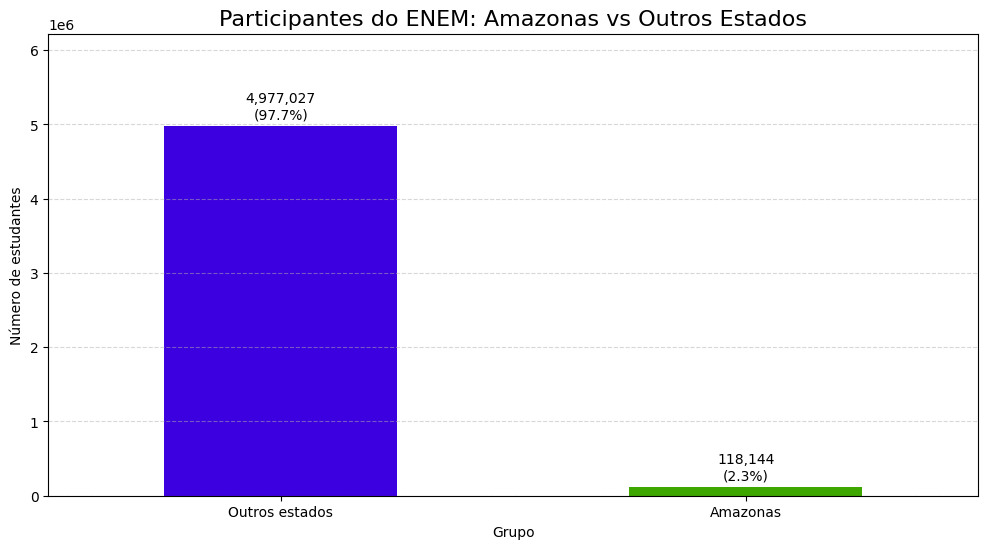

In [91]:
contagem = df['GRUPO_AM'].value_counts()
porcentagem = df['GRUPO_AM'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(12,6))

contagem.plot(
    kind='bar',
    ax=ax,
    color=["#3C00E0","#3da700"]
)

ax.set_title('Participantes do ENEM: Amazonas vs Outros Estados', fontsize=16)
ax.set_xlabel('Grupo')
ax.set_ylabel('Número de estudantes')

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=0)

# aumentar um pouco o limite do eixo
ax.set_ylim(0, contagem.max()*1.25)

# texto nas barras

offset = max(contagem) * 0.02  # 2% do maior valor

for i, v in enumerate(contagem):
    pct = porcentagem[i]
    
    ax.text(
        i,
        v + offset,
        f'{v:,}\n({pct:.1f}%)',
        ha='center',
        fontsize=10
    )
plt.show()

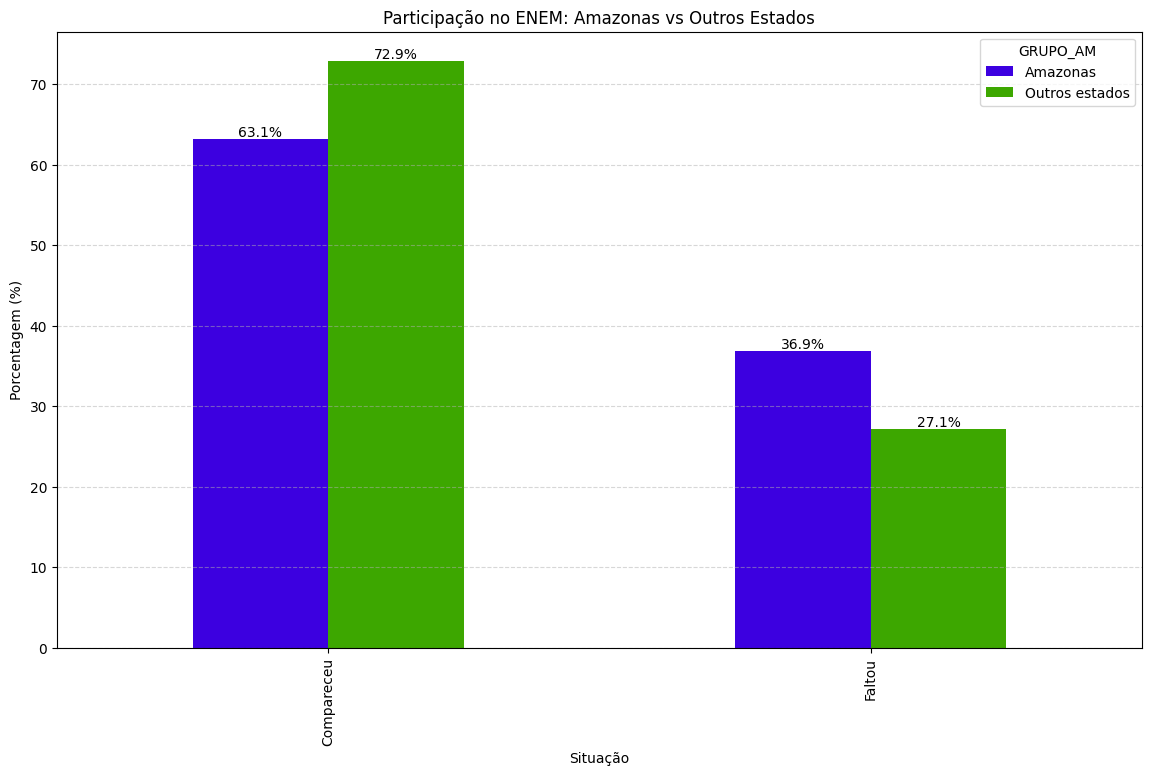

In [98]:
faltas = pd.crosstab(df['GRUPO_AM'], df['FALTOU'])

faltas = faltas.rename(columns={
    False: 'Compareceu',
    True: 'Faltou'
})

faltas_pct = faltas.div(faltas.sum(axis=1), axis=0) * 100

# 🔥 TRANSFORMAÇÃO IMPORTANTE
faltas_pct_plot = faltas_pct.T

fig, ax = plt.subplots(figsize=(14,8))

# Cores: AM vs Outros
cores = {
    'Amazonas': '#3C00E0',
    'Outros estados': '#3da700'
}

faltas_pct_plot.plot(
    kind='bar',
    ax=ax,
    color=[cores[col] for col in faltas_pct_plot.columns]
)

ax.set_title('Participação no ENEM: Amazonas vs Outros Estados')
ax.set_xlabel('Situação')
ax.set_ylabel('Porcentagem (%)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

In [51]:
df_notas = df[~df['FALTOU']]
df_notas

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,FALTOU,GRUPO_AM
3,190001199383,2019,10,F,1,1,1,1,4,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1721000,Palmas,17,TO,1,1,1,1,504.0,510.0,513.0,516.0,483.8,503.6,537.3,392.0,BACCEEBEECDBEDDAEECDEDEADEBBCDBCAACADEEACCBBD,AECEDADAABAADBAADAEBACBAECCDAEADCDBBECCEDABCD,99999AAABEBBCCBDCAEECADBACAADAECCCDCCBAEBDEEEA...,DDBBBBCDCCDCAECCBBECDAEBADCD..CABCCECAEBDBBDA,1,BEEAAEBEEBADEADDADAEABCEDDDBCBCBCCACBCDADCCEB,EEBCEEDBADBBCBABCCADCEBACDBBACCACACBEADBBADCB,ADBBEDCABAABBCBCDAAECDDDBAAAECADECDCEBDEEAECBD...,BEDEEEAADBEBACABCDBABECECACADCBDCCEDCDABECDDD,1.0,120.0,120.0,120.0,100.0,0.0,460.0,C,E,B,D,4,E,A,C,C,A,B,B,A,B,A,A,A,A,C,A,B,D,A,B,B,False,Outros estados
4,190001237802,2019,7,F,1,1,1,1,4,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3118601,Contagem,31,MG,1,1,1,1,504.0,510.0,513.0,516.0,513.6,575.5,570.7,677.0,EEBEDEEEEEBDCEEBEEEEABEEBEEBAEDEECECCDBCECEAE,EEDCCEDDBCBEABAAABADCEDABDBBCBDCCCCDAEDEDBDCB,ABBBE99999ABBCACCCAEEEDCCDADCCAEDEDDEEDBBDECBD...,CDEEEEEAEECBABABCDCACEEEEEEDEEACEAEDEBEEECEDE,0,BEEAAEBEEBADEADDADAEABCEDDDBCBCBCCACBCDADCCEB,EEBCEEDBADBBCBABCCADCEBACDBBACCACACBEADBBADCB,ADBBEDCABAABBCBCDAAECDDDBAAAECADECDCEBDEEAECBD...,BEDEEEAADBEBACABCDBABECECACADCBDCCEDCDABECDDD,1.0,160.0,120.0,180.0,200.0,200.0,860.0,E,E,C,C,3,G,A,C,D,B,A,B,B,B,A,B,A,A,B,A,A,C,B,B,B,False,Outros estados
5,190001782198,2019,13,M,2,2,1,1,13,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5107602,Rondonópolis,51,MT,1,1,1,1,505.0,508.0,512.0,518.0,563.7,644.9,564.2,675.3,DCDBDEDCDDBCBEADBEBBCDBDBDEBEBACABDBDADEDACAE,ABABADBECAEEBCBBDCBEEDBDEADBEACDBEEBAACABACEB,BBDDA99999ABACBECEAECECCDEAEDCDAEBDAEDEDECABCA...,DDCBADCBCDEABEACEBBCADEBEECEADBECDBADEAECACDD,0,DADCCEBBCCACBEEBEEBACBCDDDDADBCBBCEAEADEADAAE,CBABADBBCEEEBCBADCBEEDBBEADBBACDBBACCCCADACAC,BBEDABDACACBABAECBBCCADCEBDBBCDDEEAAADDBECDECA...,DBEBACABCDBABECEEEDCBDCCEDCDABEDAADDDECACAECB,1.0,160.0,200.0,180.0,180.0,80.0,800.0,B,B,C,B,7,E,A,B,D,A,C,B,A,B,A,B,A,A,B,A,A,E,A,B,B,False,Outros estados
6,190001421548,2019,7,F,1,3,1,1,5,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2924009,Paulo Afonso,29,BA,1,1,1,1,505.0,508.0,512.0,518.0,484.6,488.4,507.2,594.7,BADEBCACADECAEAAAECCCDEACCEA.ECCDDCECBEBADAAC,AAAECDAACDAEDCDBDCBBDDAECBBECBDDDECCACCEDEACA,99999BEDAACECEACDCDEBECACBDDECAACDBACDCAECADEA...,ACBBAECECDBDDDCEDCEACDBCDCDDAAEAEDDCECDCBDECB,1,DADCCEBBCCACBEEBEEBACBCDDDDADBCBBCEAEADEADAAE,CBABADBBCEEEBCBADCBEEDBBEADBBACDBBACCCCADACAC,BBEDABDACACBABAECBBCCADCEBDBBCDDEEAAADDBECDECA...,DBEBACABCDBABECEEEDCBDCCEDCDABEDAADDDECACAECB,1.0,140.0,120.0,120.0,160.0,60.0,600.0,E,B,C,B,3,B,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,B,A,A,A,False,Outros estados
9,190001592266,2019,2,M,1,1,1,2,0,2,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3550308,São Paulo,35,SP,1,1,1,1,505.0,509.0,514.0,518.0,543.9,548.1,502.5,480.7,BADADDBADBBECEBBCECBCBEBBBCBABDECDEACADDADCEE,CDACAEDDABABADCEBABCBEEBACBBCBCDADCEEDABCAADA,EBBBC99999BCDBEBEECCDACDADEBABCBDDBDDBAEECCBAC...,DACCDBCBBDDDCCAECBABBABCCBCEBDBCBBBACCBCCEDCB,0,DADCCEBBCCACBEEBEEBACBCDDDDADBCBBCEAEADEADAAE,ACACEEBCCBABADBBBACDBBACCCCADCEBADCBEEDBBEADB,EBBADCABDABACBCEBDEEAAADDBECDECDDBADBCDAAECBCC...,DBEBACABCDBABECEEEDCBDCCEDCDABEDAADDDECACAECB,1.0,120.0,40.0,120.0,120.0,0.0,400.0,E,E,B,B,5,F,A,B,C,

In [52]:
len(df_notas)

3701910

In [53]:
len(df)

5095171

In [54]:
df_notas = df_notas[df_notas['TP_STATUS_REDACAO'] == 1]

In [55]:
df_notas['NOTA_TOTAL'] = (
    df_notas['NU_NOTA_CN'] +
    df_notas['NU_NOTA_CH'] +
    df_notas['NU_NOTA_LC'] +
    df_notas['NU_NOTA_MT'] +
    df_notas['NU_NOTA_REDACAO']
)

C:\Users\USER\AppData\Local\Temp\ipykernel_4580\2487729683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notas['NOTA_TOTAL'] = (


In [56]:
df_notas['MEDIA_NOTAS'] = df_notas[
    ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT']
].mean(axis=1)

C:\Users\USER\AppData\Local\Temp\ipykernel_4580\1879926154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notas['MEDIA_NOTAS'] = df_notas[


In [57]:
traducao_renda = {
'A':'Nenhuma renda',
'B':'Até R$ 954',
'C':'954 a 1431',
'D':'1431 a 1908',
'E':'1908 a 2385',
'F':'2385 a 2862',
'G':'2862 a 3816',
'H':'3816 a 4770',
'I':'4770 a 5724',
'J':'5724 a 6678',
'K':'6678 a 7632',
'L':'7632 a 8586',
'M':'8586 a 9540',
'N':'9540 a 11448',
'O':'11448 a 14310',
'P':'14310 a 19080',
'Q':'Mais de 19080'
}

df_notas['RENDA'] = df_notas['Q006'].map(traducao_renda)

C:\Users\USER\AppData\Local\Temp\ipykernel_4580\3373236824.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notas['RENDA'] = df_notas['Q006'].map(traducao_renda)


In [58]:
df_notas.groupby('GRUPO_AM')[[
'NU_NOTA_CN',
'NU_NOTA_CH',
'NU_NOTA_LC',
'NU_NOTA_MT',
'NU_NOTA_REDACAO'
]].mean()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
GRUPO_AM,,,,,
Amazonas,452.648288,486.591285,504.326814,483.379594,543.680725
Outros estados,479.978902,512.505086,524.728410,526.124688,597.911072


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\143211790.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pct = porcentagem[i]


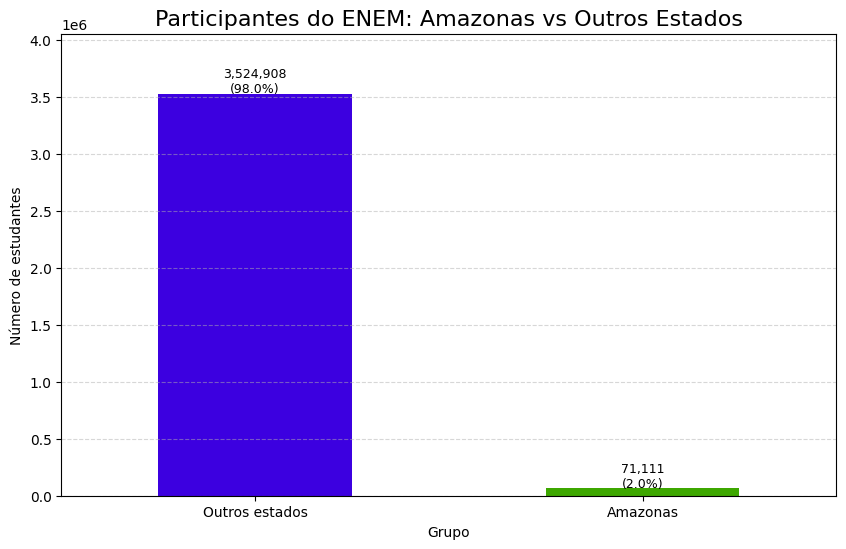

In [99]:
contagem = df_notas['GRUPO_AM'].value_counts()
porcentagem = df_notas['GRUPO_AM'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10,6))

contagem.plot(
    kind='bar',
    ax=ax,
    color=['#3C00E0','#3da700']
)

ax.set_title('Participantes do ENEM: Amazonas vs Outros Estados', fontsize=16)
ax.set_xlabel('Grupo')
ax.set_ylabel('Número de estudantes')

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=0)

# aumentar um pouco o limite do eixo
ax.set_ylim(0, contagem.max()*1.15)

# texto nas barras
for i, v in enumerate(contagem):
    
    pct = porcentagem[i]
    
    ax.text(
        i,
        v + (v * 0.005),
        f'{v:,}\n({pct:.1f}%)',
        ha='center',
        fontsize=9
    )

plt.show()

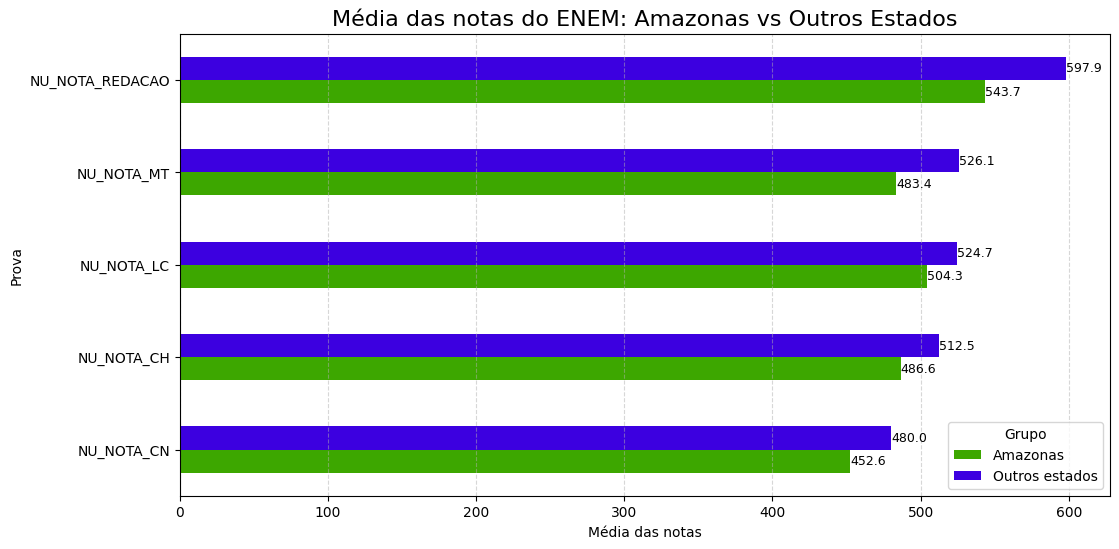

In [101]:
medias = df_notas.groupby('GRUPO_AM')[[
'NU_NOTA_CN',
'NU_NOTA_CH',
'NU_NOTA_LC',
'NU_NOTA_MT',
'NU_NOTA_REDACAO'
]].mean()

# inverter linhas e colunas
medias_t = medias.T

fig, ax = plt.subplots(figsize=(12,6))

medias_t.plot(
    kind='barh',
    ax=ax,
    color=['#3da700','#3C00E0']
)

ax.set_title('Média das notas do ENEM: Amazonas vs Outros Estados', fontsize=16)
ax.set_xlabel('Média das notas')
ax.set_ylabel('Prova')

ax.grid(axis='x', linestyle='--', alpha=0.5)

# valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.legend(title='Grupo')

plt.show()

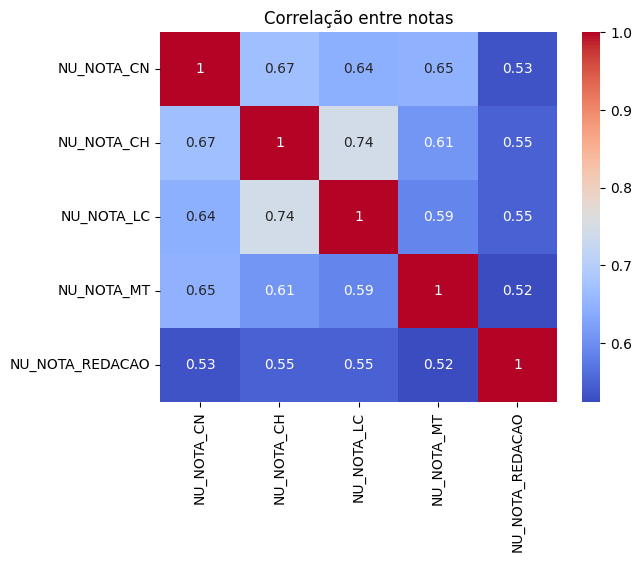

In [61]:
colunas_notas = [
'NU_NOTA_CN',
'NU_NOTA_CH',
'NU_NOTA_LC',
'NU_NOTA_MT',
'NU_NOTA_REDACAO'
]

correlacao = df_notas[colunas_notas].corr()

sns.heatmap(correlacao, annot=True, cmap='coolwarm')

plt.title('Correlação entre notas')
plt.show()

In [62]:
df_am = df_notas[df_notas['GRUPO_AM'] == 'Amazonas']

df_am[colunas_notas].corr()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
NU_NOTA_CN,1.000000,0.571145,0.562422,0.525651,0.446954
NU_NOTA_CH,0.571145,1.000000,0.684705,0.489513,0.470122
NU_NOTA_LC,0.562422,0.684705,1.000000,0.495143,0.507327
NU_NOTA_MT,0.525651,0.489513,0.495143,1.000000,0.422244
NU_NOTA_REDACAO,0.446954,0.470122,0.507327,0.422244,1.000000


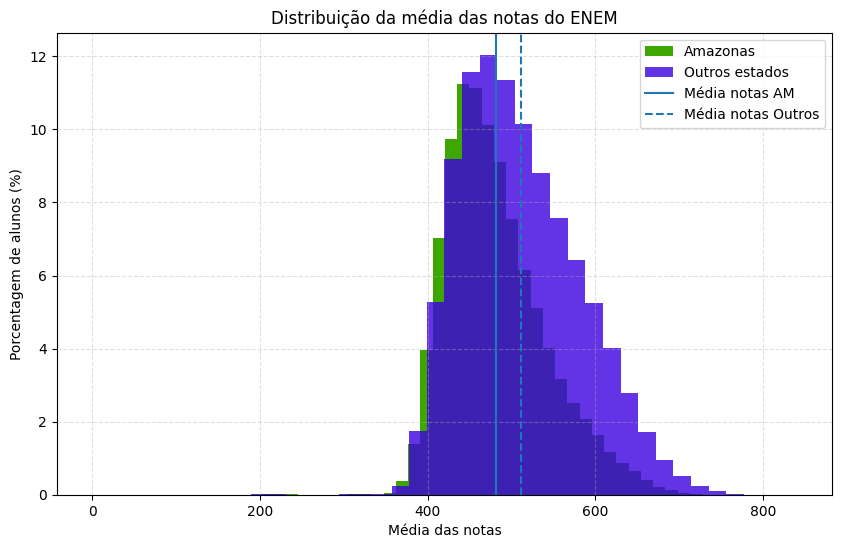

In [ ]:
import numpy as np

am = df_notas[df_notas['GRUPO_AM'] == 'Amazonas']
outros = df_notas[df_notas['GRUPO_AM'] == 'Outros estados']

fig, ax = plt.subplots(figsize=(10,6))

# pesos para converter em porcentagem
pesos_am = np.ones(len(am['MEDIA_NOTAS'])) / len(am['MEDIA_NOTAS']) * 100
pesos_outros = np.ones(len(outros['MEDIA_NOTAS'])) / len(outros['MEDIA_NOTAS']) * 100

ax.hist(am['MEDIA_NOTAS'], bins=40, alpha=1.0, label='Amazonas', weights=pesos_am, color='#3da700')
ax.hist(outros['MEDIA_NOTAS'], bins=40, alpha=0.8, label='Outros estados', weights=pesos_outros, color='#3C00E0')

ax.set_title('Distribuição da média das notas do ENEM')
ax.set_xlabel('Média das notas')
ax.set_ylabel('Porcentagem de alunos (%)')

ax.grid(True, linestyle='--', alpha=0.4)

# linhas de média
ax.axvline(am['MEDIA_NOTAS'].mean(), linestyle='-', label='Média notas AM')
ax.axvline(outros['MEDIA_NOTAS'].mean(), linestyle='--', label='Média notas Outros')

ax.legend()

plt.show()

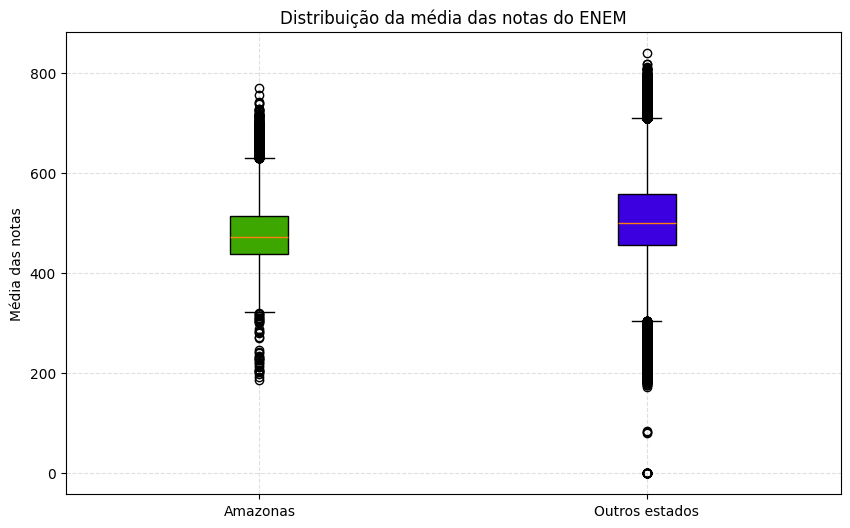

In [106]:
fig, ax = plt.subplots(figsize=(10,6))

dados = [
    df_notas[df_notas['GRUPO_AM'] == 'Amazonas']['MEDIA_NOTAS'],
    df_notas[df_notas['GRUPO_AM'] == 'Outros estados']['MEDIA_NOTAS']
]

box = ax.boxplot(dados, tick_labels=['Amazonas','Outros estados'], patch_artist=True)

cores = ['#3da700','#3C00E0']

for patch, cor in zip(box['boxes'], cores):
    patch.set_facecolor(cor)

ax.set_title('Distribuição da média das notas do ENEM')
ax.set_ylabel('Média das notas')

ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

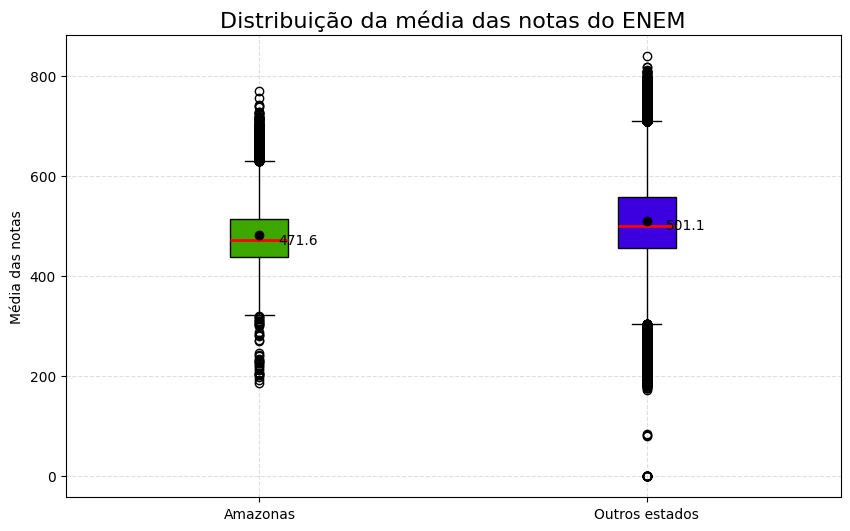

In [107]:
fig, ax = plt.subplots(figsize=(10,6))

am = df_notas[df_notas['GRUPO_AM'] == 'Amazonas']['MEDIA_NOTAS']
outros = df_notas[df_notas['GRUPO_AM'] == 'Outros estados']['MEDIA_NOTAS']

dados = [am, outros]

box = ax.boxplot(
    dados,
    tick_labels=['Amazonas','Outros estados'],
    patch_artist=True,
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black"},
    medianprops={"color":"red","linewidth":2}
)

cores = ['#3da700','#3C00E0']

for patch, cor in zip(box['boxes'], cores):
    patch.set_facecolor(cor)

ax.set_title('Distribuição da média das notas do ENEM', fontsize=16)
ax.set_ylabel('Média das notas')

ax.grid(True, linestyle='--', alpha=0.4)

# mostrar valor da mediana
medianas = [np.median(am), np.median(outros)]

for i, med in enumerate(medianas):
    ax.text(i+1.05, med, f'{med:.1f}', va='center', fontsize=10)

plt.show()

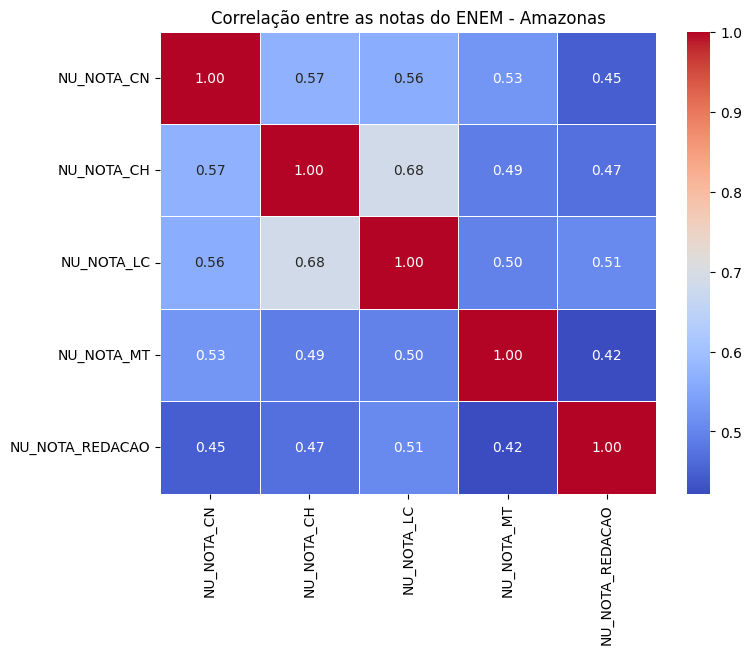

In [66]:
am = df_notas[df_notas['GRUPO_AM'] == 'Amazonas']

# selecionar notas
notas_am = am[[
'NU_NOTA_CN',
'NU_NOTA_CH',
'NU_NOTA_LC',
'NU_NOTA_MT',
'NU_NOTA_REDACAO'
]]

# calcular correlação
corr = notas_am.corr()

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlação entre as notas do ENEM - Amazonas')

plt.show()

In [67]:
estatisticas = df_notas.groupby('GRUPO_AM')['MEDIA_NOTAS'].agg([
    'mean',
    'median',
    'std'
])

estatisticas = estatisticas.rename(columns={
    'mean': 'Média',
    'median': 'Mediana',
    'std': 'Desvio Padrão'
})

estatisticas

,Média,Mediana,Desvio Padrão
GRUPO_AM,,,
Amazonas,481.736495,471.575,59.155502
Outros estados,510.834272,501.100,70.308781


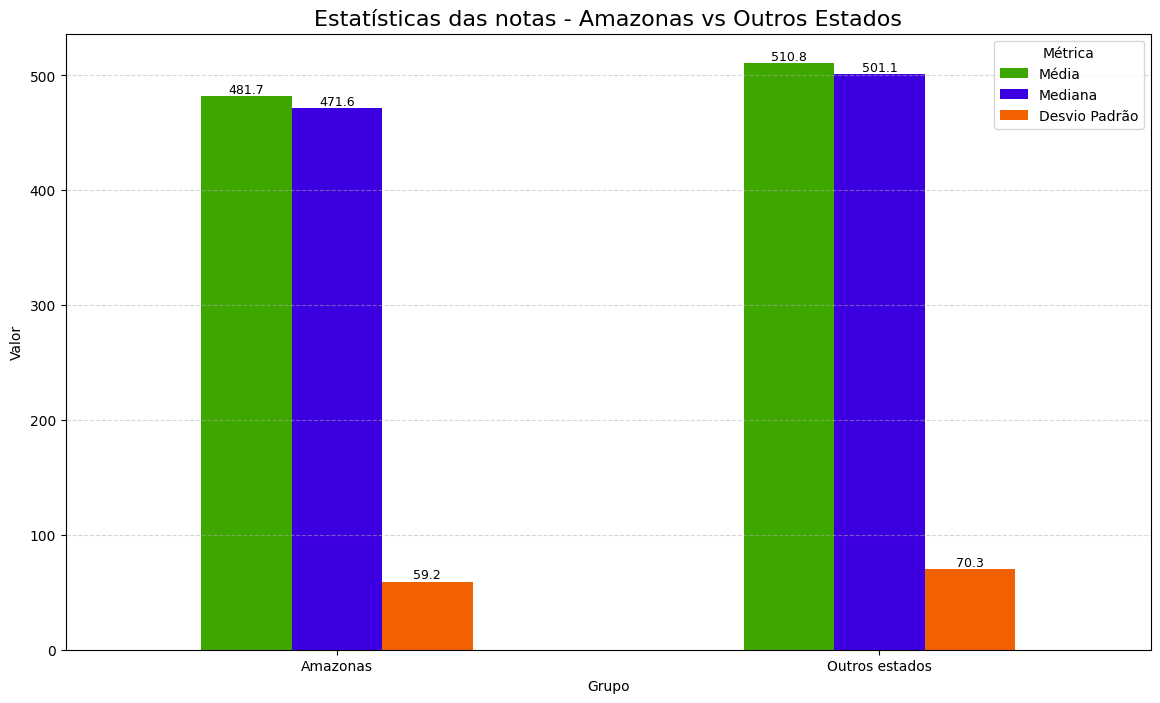

In [110]:
fig, ax = plt.subplots(figsize=(14,8))

estatisticas.plot(kind='bar',
                   ax=ax,
                   color=['#3da700','#3C00E0', "#f16100"])

ax.set_title('Estatísticas das notas - Amazonas vs Outros Estados', fontsize=16)
ax.set_xlabel('Grupo')
ax.set_ylabel('Valor')

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=0)

# valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.legend(title='Métrica')

plt.show()

## 📊 ANÁLISES COMPLEMENTARES - APROFUNDAMENTO

As células a seguir exploram dimensões importantes dos dados: como a renda afeta o desempenho, qual disciplina mais desafia os alunos, quem são os melhores/piores alunos, e padrões estatísticos avançados.


ANÁLISE 1: IMPACTO DA RENDA NAS NOTAS DO ENEM

MÉDIAS DE NOTAS POR FAIXA DE RENDA:
              NU_NOTA_CN         NU_NOTA_CH         NU_NOTA_LC         NU_NOTA_MT         NU_NOTA_REDACAO         MEDIA_NOTAS        
                    mean   count       mean   count       mean   count       mean   count            mean   count        mean   count
RENDA                                                                                                                                
11448 a 14310     560.99   41600     589.56   41600     580.60   41600     653.43   41600          731.70   41600      596.15   41600
1431 a 1908       478.77  348374     513.36  348374     526.94  348374     523.11  348374          589.83  348374      510.55  348374
14310 a 19080     567.55   35838     595.66   35838     584.57   35838     665.32   35838          740.71   35838      603.27   35838
1908 a 2385       484.46  338990     519.61  338990     531.89  338990     530.99  338990          602.27  33899

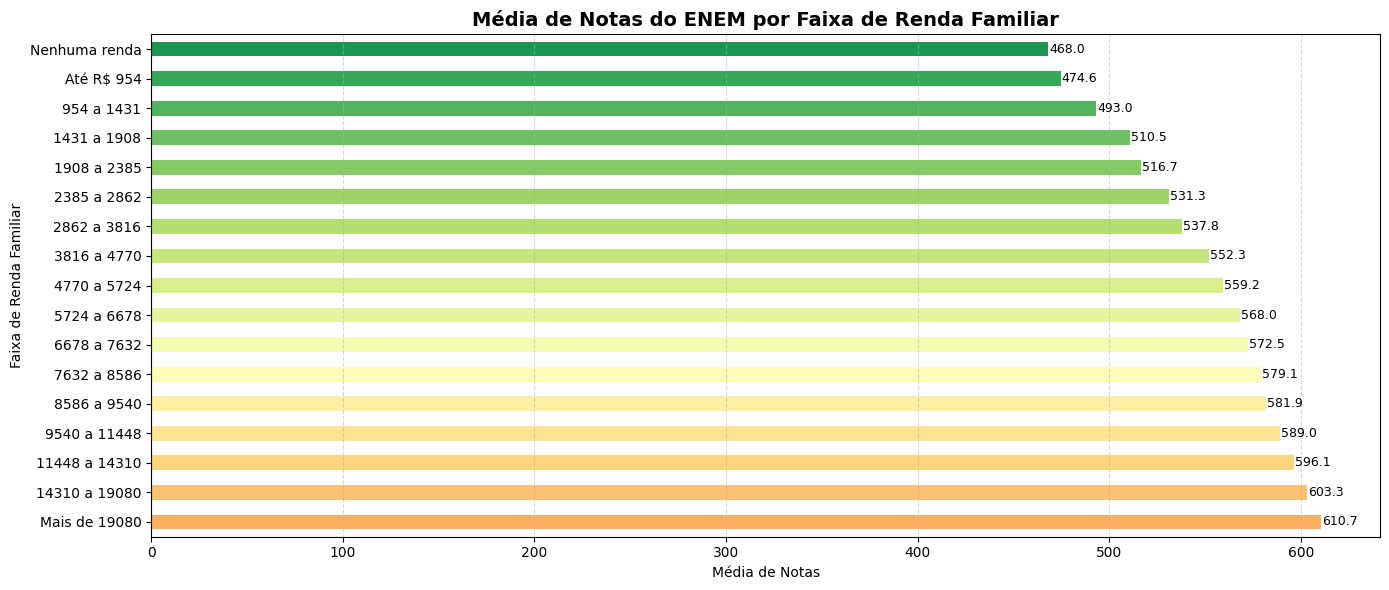


🔍 INSIGHT: Observe a correlação direta entre renda e desempenho


In [115]:
# ========================================================================
# 1️⃣  ANÁLISE POR RENDA
# ========================================================================
# Objetivo: Verificar como a renda familiar impacta nas notas (desigualdade social)
# Insight esperado: Maior renda → melhor desempenho

print("\n" + "=" * 80)
print("ANÁLISE 1: IMPACTO DA RENDA NAS NOTAS DO ENEM")
print("=" * 80)

# Agrupar por renda e calcular médias
renda_analise = df_notas.groupby('RENDA')[[
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO',
    'MEDIA_NOTAS'
]].agg(['mean', 'count']).round(2)

print("\nMÉDIAS DE NOTAS POR FAIXA DE RENDA:")
print(renda_analise)

# Gráfico: Média de notas por renda
fig, ax = plt.subplots(figsize=(14, 6))

renda_medias = df_notas.groupby('RENDA')['MEDIA_NOTAS'].mean().sort_values(ascending=False)
cores_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(renda_medias)))

renda_medias.plot(kind='barh', ax=ax, color=cores_gradient)

ax.set_title('Média de Notas do ENEM por Faixa de Renda Familiar', fontsize=14, fontweight='bold')
ax.set_xlabel('Média de Notas')
ax.set_ylabel('Faixa de Renda Familiar')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Label nas barras
for i, v in enumerate(renda_medias):
    ax.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT: Observe a correlação direta entre renda e desempenho")


ANÁLISE 2: DESEMPENHO POR DISCIPLINA

ESTATÍSTICAS COMPLETAS POR DISCIPLINA:
                        mean  median     std   min     max
Ciências da Natureza  479.44   472.4   76.01   0.0   860.9
Ciências Humanas      511.99   515.7   80.28   0.0   835.1
Linguagens            524.32   529.4   61.64   0.0   801.7
Matemática            525.28   503.9  109.25   0.0   985.5
Redação               596.84   580.0  155.25  40.0  1000.0


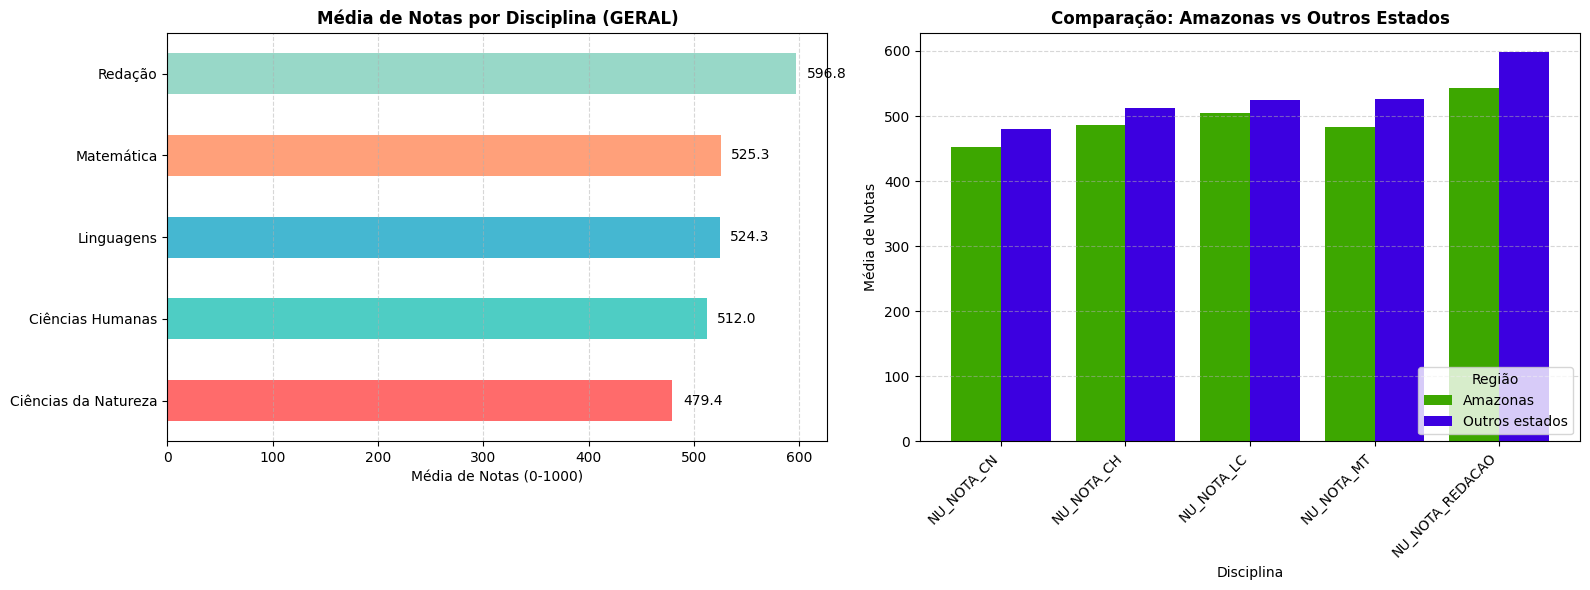


🔍 INSIGHT: Matemática é geralmente a disciplina mais difícil (menores notas)


In [116]:
# ========================================================================
# 2️⃣  DESEMPENHO POR DISCIPLINA
# ========================================================================
# Objetivo: Identificar quais disciplinas são mais fáceis/difíceis
# Insight esperado: Qual área do conhecimento os alunos dominam melhor

print("\n" + "=" * 80)
print("ANÁLISE 2: DESEMPENHO POR DISCIPLINA")
print("=" * 80)

# Estatísticas por disciplina
disciplinas = {
    'Ciências da Natureza': 'NU_NOTA_CN',
    'Ciências Humanas': 'NU_NOTA_CH',
    'Linguagens': 'NU_NOTA_LC',
    'Matemática': 'NU_NOTA_MT',
    'Redação': 'NU_NOTA_REDACAO'
}

stats_disciplinas = pd.DataFrame({
    nome: df_notas[col].agg(['mean', 'median', 'std', 'min', 'max'])
    for nome, col in disciplinas.items()
}).T.round(2)

print("\nESTATÍSTICAS COMPLETAS POR DISCIPLINA:")
print(stats_disciplinas)

# Gráfico 1: Comparação de médias por disciplina e região
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por disciplina global
medias_disc = pd.Series({nome: df_notas[col].mean() for nome, col in disciplinas.items()})
cores_disc = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
medias_disc.plot(kind='barh', ax=axes[0], color=cores_disc)
axes[0].set_title('Média de Notas por Disciplina (GERAL)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Média de Notas (0-1000)')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(medias_disc):
    axes[0].text(v + 10, i, f'{v:.1f}', va='center', fontsize=10)

# Por disciplina e região
medias_disc_grupo = df_notas.groupby('GRUPO_AM')[[col for col in disciplinas.values()]].mean()
medias_disc_grupo_t = medias_disc_grupo.T
medias_disc_grupo_t.plot(kind='bar', ax=axes[1], color=['#3da700', '#3C00E0'], width=0.8)
axes[1].set_title('Comparação: Amazonas vs Outros Estados', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Média de Notas')
axes[1].set_xlabel('Disciplina')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Região', loc='lower right')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT: Matemática é geralmente a disciplina mais difícil (menores notas)")


ANÁLISE 3: TOP E BOTTOM PERFORMERS

TOP 10% (acima de 609.9 pontos): 359,635 alunos
BOTTOM 10% (abaixo de 426.6 pontos): 359,609 alunos

📊 Distribuição Top 10% por Região:
  Amazonas: 2,537 (0.7%)
  Outros estados: 357,098 (99.3%)

📊 Distribuição Bottom 10% por Região:
  Amazonas: 11,779 (3.3%)
  Outros estados: 347,830 (96.7%)


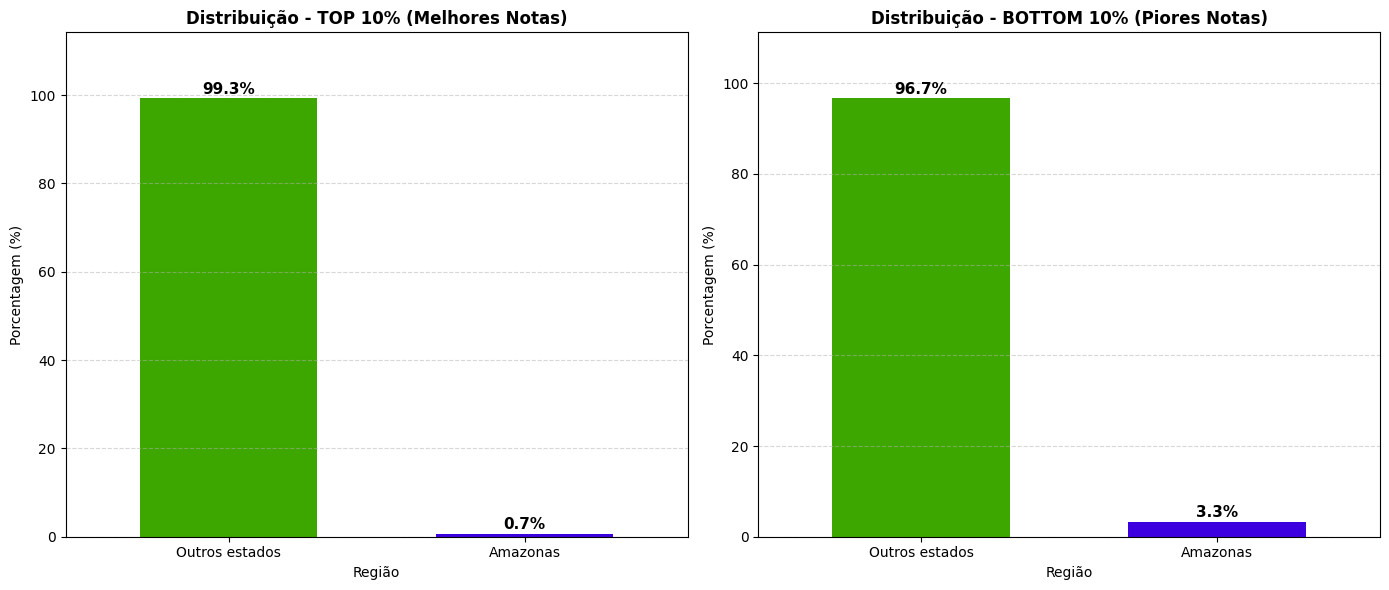


🔍 INSIGHT: Amazonas está SUB-REPRESENTADA entre top performers


In [117]:
# ========================================================================
# 3️⃣  TOP E BOTTOM PERFORMERS
# ========================================================================
# Objetivo: Identificar melhor e pior desempenho por grupo
# Insight esperado: Quem são os alunos com melhor/pior nota

print("\n" + "=" * 80)
print("ANÁLISE 3: TOP E BOTTOM PERFORMERS")
print("=" * 80)

# Definir top (top 10%) e bottom (bottom 10%)
p90 = df_notas['MEDIA_NOTAS'].quantile(0.90)
p10 = df_notas['MEDIA_NOTAS'].quantile(0.10)

top_performers = df_notas[df_notas['MEDIA_NOTAS'] >= p90]
bottom_performers = df_notas[df_notas['MEDIA_NOTAS'] <= p10]

print(f"\nTOP 10% (acima de {p90:.1f} pontos): {len(top_performers):,} alunos")
print(f"BOTTOM 10% (abaixo de {p10:.1f} pontos): {len(bottom_performers):,} alunos")

# Distribuição por região
print("\n📊 Distribuição Top 10% por Região:")
top_dist = top_performers['GRUPO_AM'].value_counts()
top_pct = (top_dist / len(top_performers) * 100).round(2)
print(f"  Amazonas: {top_dist.get('Amazonas', 0):,} ({top_pct.get('Amazonas', 0):.1f}%)")
print(f"  Outros estados: {top_dist.get('Outros estados', 0):,} ({top_pct.get('Outros estados', 0):.1f}%)")

print("\n📊 Distribuição Bottom 10% por Região:")
bottom_dist = bottom_performers['GRUPO_AM'].value_counts()
bottom_pct = (bottom_dist / len(bottom_performers) * 100).round(2)
print(f"  Amazonas: {bottom_dist.get('Amazonas', 0):,} ({bottom_pct.get('Amazonas', 0):.1f}%)")
print(f"  Outros estados: {bottom_dist.get('Outros estados', 0):,} ({bottom_pct.get('Outros estados', 0):.1f}%)")

# Gráfico: Distribuição de performers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top performers
top_dist_plot = (top_dist / len(top_performers) * 100)
top_dist_plot.plot(kind='bar', ax=axes[0], color=['#3da700', '#3C00E0'], width=0.6)
axes[0].set_title('Distribuição - TOP 10% (Melhores Notas)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Porcentagem (%)')
axes[0].set_xlabel('Região')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(top_dist_plot):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(top_dist_plot) * 1.15)

# Bottom performers
bottom_dist_plot = (bottom_dist / len(bottom_performers) * 100)
bottom_dist_plot.plot(kind='bar', ax=axes[1], color=['#3da700', '#3C00E0'], width=0.6)
axes[1].set_title('Distribuição - BOTTOM 10% (Piores Notas)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentagem (%)')
axes[1].set_xlabel('Região')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(bottom_dist_plot):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, max(bottom_dist_plot) * 1.15)

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT: Amazonas está SUB-REPRESENTADA entre top performers")


ANÁLISE 4: QUARTIS E PERCENTIS - POSICIONAMENTO RELATIVO

📍 QUARTIS (Divisão em 4 partes):
  Q1 (25º percentil): 456.1 - 75% dos alunos ficaram acima deste valor
  Q2 (50º percentil/Mediana): 500.4 - 50% acima, 50% abaixo
  Q3 (75º percentil): 557.5 - 25% dos alunos ficaram acima deste valor

📍 PERCENTIS SELECIONADOS:
  P10: 426.6
  P25: 456.1
  P50: 500.4
  P75: 557.5
  P90: 609.9


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\2726470484.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notas['QUARTIL'] = df_notas['MEDIA_NOTAS'].apply(classificar_quartil)



📊 DISTRIBUIÇÃO POR QUARTIL:

Número absoluto:
QUARTIL         Q1 (Abaixo de 25%)  Q2 (25%-50%)  Q3 (50%-75%)  Q4 (Top 25%)      All
GRUPO_AM                                                                             
Amazonas                     27601         20681         14518          8311    71111
Outros estados              871611        878212        884471        890614  3524908
All                         899212        898893        898989        898925  3596019

Porcentagem dentro de cada região (%):
QUARTIL         Q1 (Abaixo de 25%)  Q2 (25%-50%)  Q3 (50%-75%)  Q4 (Top 25%)
GRUPO_AM                                                                    
Amazonas                     38.81         29.08         20.42         11.69
Outros estados               24.73         24.91         25.09         25.27


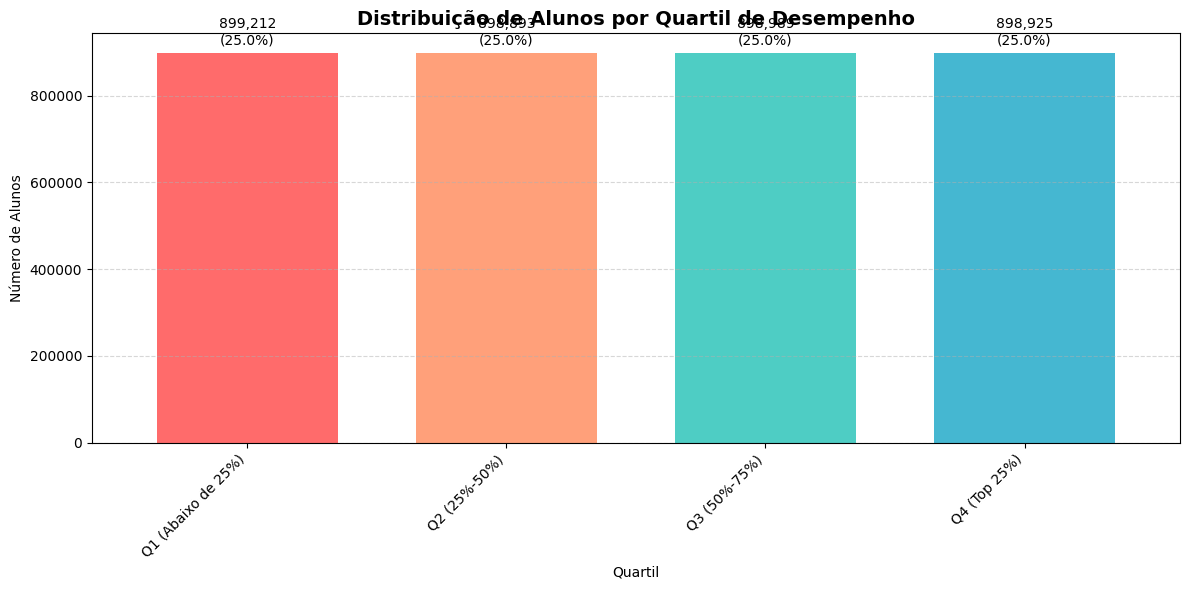


🔍 INSIGHT: A distribuição deve ser aproximadamente 25% em cada quartil


In [118]:
# ========================================================================
# 4️⃣  ANÁLISE DE QUARTIS E PERCENTIS
# ========================================================================
# O QUE SÃO QUARTIS E PERCENTIS?
# 
# QUARTIS: Dividem os dados em 4 partes iguais (25% cada)
#   Q1 (25º percentil): 25% dos alunos ficaram abaixo deste valor
#   Q2 (50º percentil / Mediana): 50% ficaram abaixo, 50% acima
#   Q3 (75º percentil): 75% ficaram abaixo deste valor
#
# PERCENTIS: Valores que dividem os dados em 100 partes iguais (1% cada)
#   P10 = valor abaixo do qual 10% dos dados se encontram
#   P90 = valor abaixo do qual 90% dos dados se encontram
#
# EXEMPLO: Se sua nota é Q3, você está entre os 25% melhores!

print("\n" + "=" * 80)
print("ANÁLISE 4: QUARTIS E PERCENTIS - POSICIONAMENTO RELATIVO")
print("=" * 80)

# Calcular quartis e percentis
quartis = df_notas['MEDIA_NOTAS'].quantile([0.25, 0.50, 0.75])
percentis_selecionados = df_notas['MEDIA_NOTAS'].quantile([0.10, 0.25, 0.50, 0.75, 0.90])

print("\n📍 QUARTIS (Divisão em 4 partes):")
print(f"  Q1 (25º percentil): {quartis[0.25]:.1f} - 75% dos alunos ficaram acima deste valor")
print(f"  Q2 (50º percentil/Mediana): {quartis[0.50]:.1f} - 50% acima, 50% abaixo")
print(f"  Q3 (75º percentil): {quartis[0.75]:.1f} - 25% dos alunos ficaram acima deste valor")

print("\n📍 PERCENTIS SELECIONADOS:")
for perc, valor in percentis_selecionados.items():
    print(f"  P{int(perc*100)}: {valor:.1f}")

# Categorizar alunos por quartil
def classificar_quartil(nota):
    if nota <= quartis[0.25]:
        return 'Q1 (Abaixo de 25%)'
    elif nota <= quartis[0.50]:
        return 'Q2 (25%-50%)'
    elif nota <= quartis[0.75]:
        return 'Q3 (50%-75%)'
    else:
        return 'Q4 (Top 25%)'

df_notas['QUARTIL'] = df_notas['MEDIA_NOTAS'].apply(classificar_quartil)

# Análise por grupo e quartil
quartil_analise = pd.crosstab(df_notas['GRUPO_AM'], df_notas['QUARTIL'], margins=True)
quartil_analise_pct = pd.crosstab(
    df_notas['GRUPO_AM'],
    df_notas['QUARTIL'],
    normalize='index'
) * 100

print("\n📊 DISTRIBUIÇÃO POR QUARTIL:")
print("\nNúmero absoluto:")
print(quartil_analise)
print("\nPorcentagem dentro de cada região (%):")
print(quartil_analise_pct.round(2))

# Gráfico: Distribuição por quartil
fig, ax = plt.subplots(figsize=(12, 6))

quartil_plot = df_notas['QUARTIL'].value_counts().sort_index()
cores_quartil = ['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1']

quartil_plot.plot(kind='bar', ax=ax, color=cores_quartil, width=0.7)
ax.set_title('Distribuição de Alunos por Quartil de Desempenho', fontsize=14, fontweight='bold')
ax.set_xlabel('Quartil')
ax.set_ylabel('Número de Alunos')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

for i, v in enumerate(quartil_plot):
    pct = v / len(df_notas) * 100
    ax.text(i, v + 20000, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT: A distribuição deve ser aproximadamente 25% em cada quartil")


ANÁLISE 5: COMPARATIVO DE REDAÇÃO


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\2034896464.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notas['MEDIA_4_PROVAS'] = df_notas[[



📊 ESTATÍSTICAS DA REDAÇÃO:
  Média geral: 596.8
  Mediana: 580.0
  Desvio Padrão: 155.2
  Mínima: 40.0
  Máxima: 1000.0

📊 CORRELAÇÃO REDAÇÃO vs MÉDIA DE PROVAS: 0.626
  (Correlação próxima a 1 = forte relação positiva)

📊 MÉDIAS DE NOTAS POR GRUPO:
               NU_NOTA_REDACAO         MEDIA_4_PROVAS        MEDIA_NOTAS       
                          mean     std           mean    std        mean    std
GRUPO_AM                                                                       
Amazonas                543.68  137.62         481.74  59.16      481.74  59.16
Outros estados          597.91  155.40         510.83  70.31      510.83  70.31


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\2034896464.py:97: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


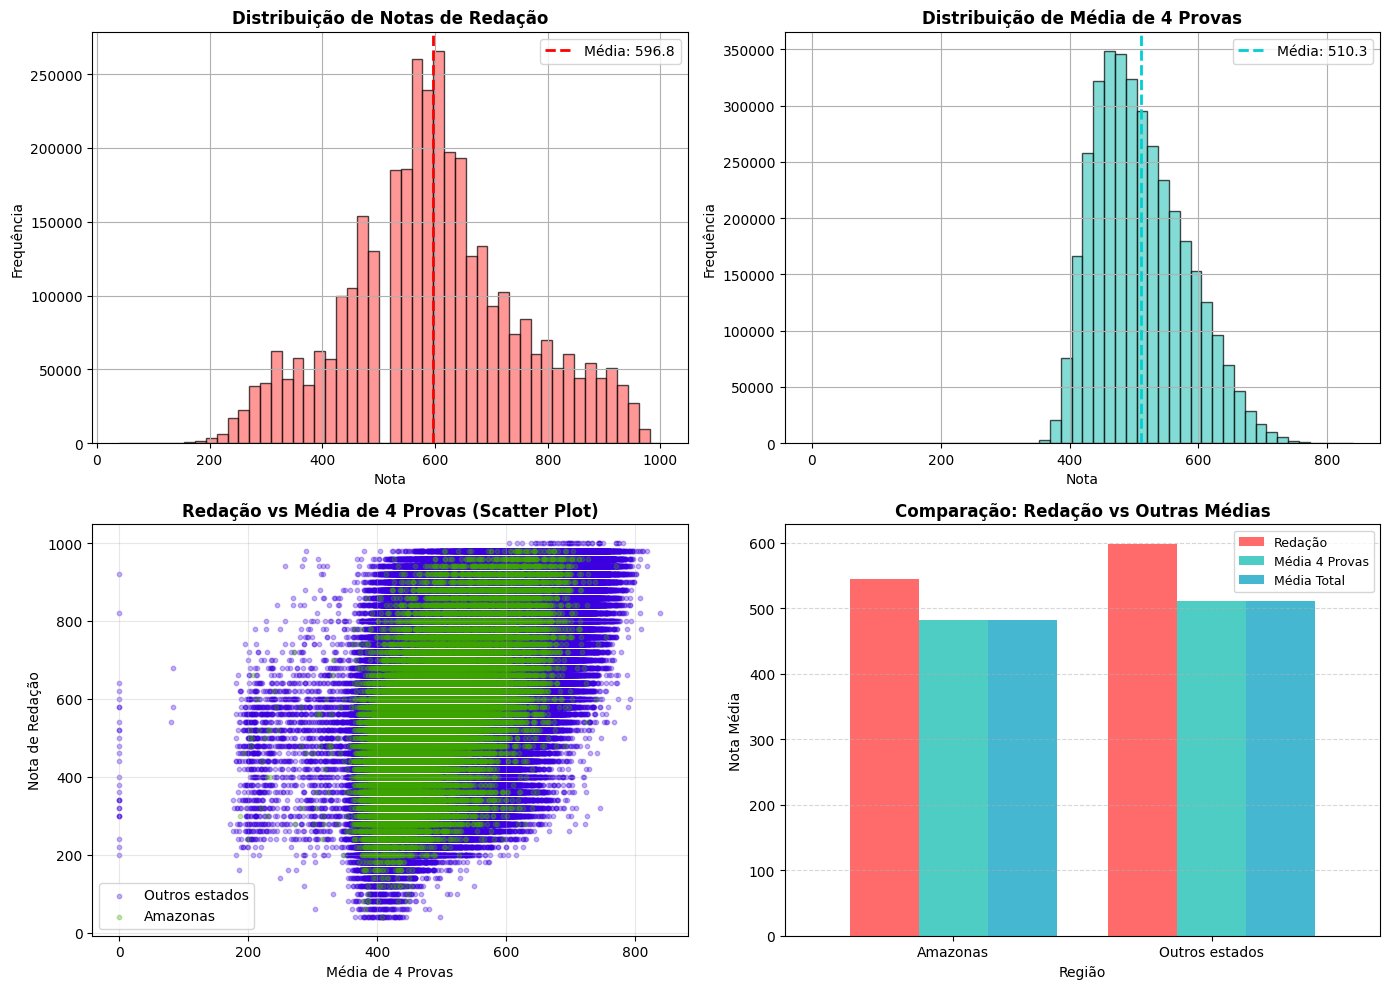


🔍 INSIGHT: Redação = indicador forte de desempenho geral


In [119]:
# ========================================================================
# 5️⃣  COMPARATIVO DE REDAÇÃO
# ========================================================================
# Objetivo: Analisar como redação complementa o desempenho geral
# Insight esperado: Redação é mais/menos importante que média das provas?

print("\n" + "=" * 80)
print("ANÁLISE 5: COMPARATIVO DE REDAÇÃO")
print("=" * 80)

# Comparar redação com média das 4 provas
df_notas['MEDIA_4_PROVAS'] = df_notas[[
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT'
]].mean(axis=1)

# Correlação entre redação e média de provas
corr_redacao = df_notas['NU_NOTA_REDACAO'].corr(df_notas['MEDIA_4_PROVAS'])

print(f"\n📊 ESTATÍSTICAS DA REDAÇÃO:")
print(f"  Média geral: {df_notas['NU_NOTA_REDACAO'].mean():.1f}")
print(f"  Mediana: {df_notas['NU_NOTA_REDACAO'].median():.1f}")
print(f"  Desvio Padrão: {df_notas['NU_NOTA_REDACAO'].std():.1f}")
print(f"  Mínima: {df_notas['NU_NOTA_REDACAO'].min():.1f}")
print(f"  Máxima: {df_notas['NU_NOTA_REDACAO'].max():.1f}")

print(f"\n📊 CORRELAÇÃO REDAÇÃO vs MÉDIA DE PROVAS: {corr_redacao:.3f}")
print("  (Correlação próxima a 1 = forte relação positiva)")

# Análise por grupo
stats_redac_grupo = df_notas.groupby('GRUPO_AM')[[
    'NU_NOTA_REDACAO',
    'MEDIA_4_PROVAS',
    'MEDIA_NOTAS'
]].agg(['mean', 'std']).round(2)

print("\n📊 MÉDIAS DE NOTAS POR GRUPO:")
print(stats_redac_grupo)

# Gráfico: Redação vs Média de 4 Provas por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição da Redação
df_notas['NU_NOTA_REDACAO'].hist(bins=50, ax=axes[0, 0], color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribuição de Notas de Redação', fontweight='bold')
axes[0, 0].set_xlabel('Nota')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].axvline(df_notas['NU_NOTA_REDACAO'].mean(), color='red', linestyle='--', linewidth=2, label=f"Média: {df_notas['NU_NOTA_REDACAO'].mean():.1f}")
axes[0, 0].legend()

# 2. Distribuição da Média de 4 Provas
df_notas['MEDIA_4_PROVAS'].hist(bins=50, ax=axes[0, 1], color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribuição de Média de 4 Provas', fontweight='bold')
axes[0, 1].set_xlabel('Nota')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].axvline(df_notas['MEDIA_4_PROVAS'].mean(), color='darkturquoise', linestyle='--', linewidth=2, label=f"Média: {df_notas['MEDIA_4_PROVAS'].mean():.1f}")
axes[0, 1].legend()

# 3. Scatter: Redação vs Média de Provas (com cor por grupo)
grupos = df_notas['GRUPO_AM'].unique()
cores_scatter = {'Amazonas': '#3da700', 'Outros estados': '#3C00E0'}

for grupo in grupos:
    dados_grupo = df_notas[df_notas['GRUPO_AM'] == grupo]
    axes[1, 0].scatter(
        dados_grupo['MEDIA_4_PROVAS'],
        dados_grupo['NU_NOTA_REDACAO'],
        alpha=0.3,
        s=10,
        color=cores_scatter[grupo],
        label=grupo
    )

axes[1, 0].set_title('Redação vs Média de 4 Provas (Scatter Plot)', fontweight='bold')
axes[1, 0].set_xlabel('Média de 4 Provas')
axes[1, 0].set_ylabel('Nota de Redação')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Comparação de médias por grupo
comparacao = pd.DataFrame({
    'Redação': df_notas.groupby('GRUPO_AM')['NU_NOTA_REDACAO'].mean(),
    'Média 4 Provas': df_notas.groupby('GRUPO_AM')['MEDIA_4_PROVAS'].mean(),
    'Média Total': df_notas.groupby('GRUPO_AM')['MEDIA_NOTAS'].mean()
})

comparacao.plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], width=0.8)
axes[1, 1].set_title('Comparação: Redação vs Outras Médias', fontweight='bold')
axes[1, 1].set_ylabel('Nota Média')
axes[1, 1].set_xlabel('Região')
axes[1, 1].legend(loc='best', fontsize=9)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT: Redação = indicador forte de desempenho geral")


ANÁLISE 6: OUTLIERS - ALUNOS EXTREMAMENTE BOM OU RUIM

📊 CÁLCULO DO MÉTODO IQR:
  Q1 (25º percentil): 456.1
  Q3 (75º percentil): 557.5
  IQR (Q3 - Q1): 101.4
  Lower Bound (Q1 - 1.5×IQR): 304.1
  Upper Bound (Q3 + 1.5×IQR): 709.5


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\4180615931.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notas['TIPO_OUTLIER'] = 'Normal'



📊 CONTAGEM DE OUTLIERS:
  Normal: 3,579,353 (99.54%)
  Outlier Baixo: 1,242 (0.03%)
  Outlier Alto: 15,424 (0.43%)

📊 DISTRIBUIÇÃO DE OUTLIERS POR REGIÃO:

Número absoluto:
TIPO_OUTLIER     Normal  Outlier Alto  Outlier Baixo
GRUPO_AM                                            
Amazonas          71053            29             29
Outros estados  3508300         15395           1213

Porcentagem (%):
TIPO_OUTLIER    Normal  Outlier Alto  Outlier Baixo
GRUPO_AM                                           
Amazonas         99.92          0.04           0.04
Outros estados   99.53          0.44           0.03


C:\Users\USER\AppData\Local\Temp\ipykernel_4580\4180615931.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 0].boxplot(


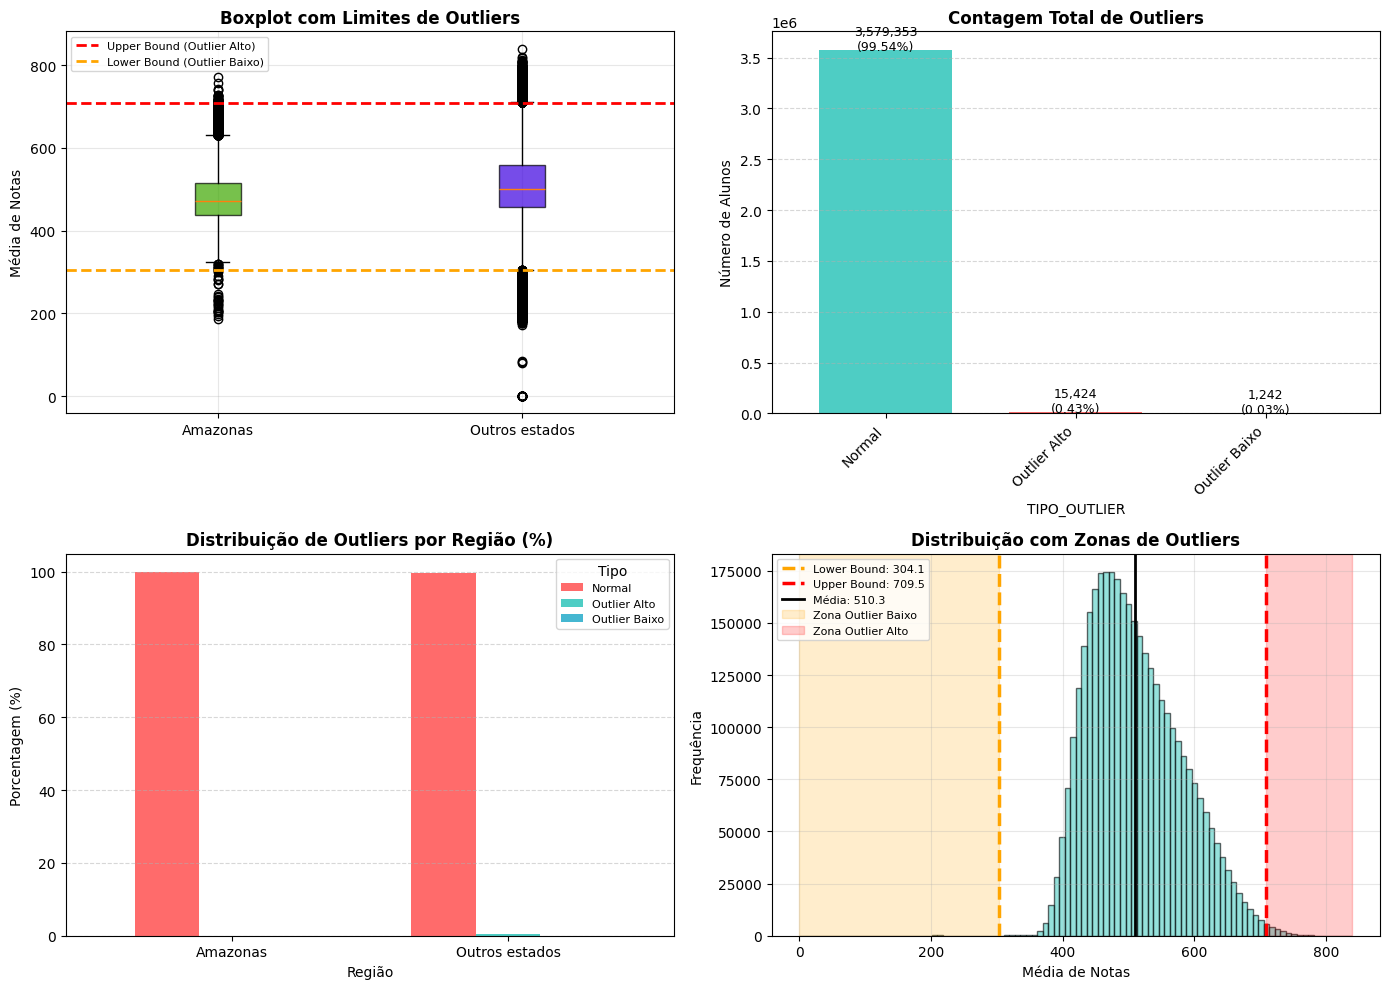


🔍 INSIGHT: Outliers podem indicar casos especiais (superdotados ou necessidade de reforço)


In [120]:
# ========================================================================
# 6️⃣  ANÁLISE DE OUTLIERS
# ========================================================================
# O QUE SÃO OUTLIERS?
# 
# Outliers são valores extremamante afastados da maioria dos dados
# Método IQR (Interquartile Range):
#   IQR = Q3 - Q1
#   Lower Bound = Q1 - 1.5 × IQR (limite inferior)
#   Upper Bound = Q3 + 1.5 × IQR (limite superior)
#   Outliers = valores fora desses límites
#
# Interpretação: Alunos muito diferentes da média (bons demais ou ruins demais)

print("\n" + "=" * 80)
print("ANÁLISE 6: OUTLIERS - ALUNOS EXTREMAMENTE BOM OU RUIM")
print("=" * 80)

# Método IQR para detectar outliers
Q1 = df_notas['MEDIA_NOTAS'].quantile(0.25)
Q3 = df_notas['MEDIA_NOTAS'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n📊 CÁLCULO DO MÉTODO IQR:")
print(f"  Q1 (25º percentil): {Q1:.1f}")
print(f"  Q3 (75º percentil): {Q3:.1f}")
print(f"  IQR (Q3 - Q1): {IQR:.1f}")
print(f"  Lower Bound (Q1 - 1.5×IQR): {lower_bound:.1f}")
print(f"  Upper Bound (Q3 + 1.5×IQR): {upper_bound:.1f}")

# Classificar outliers
df_notas['TIPO_OUTLIER'] = 'Normal'
df_notas.loc[df_notas['MEDIA_NOTAS'] < lower_bound, 'TIPO_OUTLIER'] = 'Outlier Baixo'
df_notas.loc[df_notas['MEDIA_NOTAS'] > upper_bound, 'TIPO_OUTLIER'] = 'Outlier Alto'

# Contar outliers
outlier_counts = df_notas['TIPO_OUTLIER'].value_counts()

print(f"\n📊 CONTAGEM DE OUTLIERS:")
print(f"  Normal: {outlier_counts.get('Normal', 0):,} ({(outlier_counts.get('Normal', 0)/len(df_notas)*100):.2f}%)")
print(f"  Outlier Baixo: {outlier_counts.get('Outlier Baixo', 0):,} ({(outlier_counts.get('Outlier Baixo', 0)/len(df_notas)*100):.2f}%)")
print(f"  Outlier Alto: {outlier_counts.get('Outlier Alto', 0):,} ({(outlier_counts.get('Outlier Alto', 0)/len(df_notas)*100):.2f}%)")

# Análise por grupo
outlier_grupo = pd.crosstab(df_notas['GRUPO_AM'], df_notas['TIPO_OUTLIER'])
outlier_grupo_pct = pd.crosstab(
    df_notas['GRUPO_AM'],
    df_notas['TIPO_OUTLIER'],
    normalize='index'
) * 100

print("\n📊 DISTRIBUIÇÃO DE OUTLIERS POR REGIÃO:")
print("\nNúmero absoluto:")
print(outlier_grupo)
print("\nPorcentagem (%):")
print(outlier_grupo_pct.round(2))

# Gráfico: Análise de outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot com outliers destacados
bp = axes[0, 0].boxplot(
    [df_notas[df_notas['GRUPO_AM'] == 'Amazonas']['MEDIA_NOTAS'],
     df_notas[df_notas['GRUPO_AM'] == 'Outros estados']['MEDIA_NOTAS']],
    labels=['Amazonas', 'Outros estados'],
    patch_artist=True,
    showfliers=True
)

for patch, cor in zip(bp['boxes'], ['#3da700', '#3C00E0']):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

axes[0, 0].axhline(upper_bound, color='red', linestyle='--', linewidth=2, label='Upper Bound (Outlier Alto)')
axes[0, 0].axhline(lower_bound, color='orange', linestyle='--', linewidth=2, label='Lower Bound (Outlier Baixo)')
axes[0, 0].set_title('Boxplot com Limites de Outliers', fontweight='bold')
axes[0, 0].set_ylabel('Média de Notas')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2. Contagem de outliers por tipo
outlier_plot = df_notas['TIPO_OUTLIER'].value_counts()
cores_outlier = ['#4ECDC4', '#FF6B6B', '#45B7D1']
outlier_plot.plot(kind='bar', ax=axes[0, 1], color=cores_outlier, width=0.7)
axes[0, 1].set_title('Contagem Total de Outliers', fontweight='bold')
axes[0, 1].set_ylabel('Número de Alunos')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(outlier_plot):
    pct = v / len(df_notas) * 100
    axes[0, 1].text(i, v, f'{v:,}\n({pct:.2f}%)', ha='center', fontsize=9)

# 3. Distribuição de outliers por grupo (stacked)
outlier_grupo_pct.plot(kind='bar', ax=axes[1, 0], stacked=False, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], width=0.7)
axes[1, 0].set_title('Distribuição de Outliers por Região (%)', fontweight='bold')
axes[1, 0].set_ylabel('Porcentagem (%)')
axes[1, 0].set_xlabel('Região')
axes[1, 0].legend(title='Tipo', fontsize=8)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# 4. Histograma com regiões de outliers destacadas
axes[1, 1].hist(df_notas['MEDIA_NOTAS'], bins=100, color='#4ECDC4', alpha=0.6, edgecolor='black')
axes[1, 1].axvline(lower_bound, color='orange', linestyle='--', linewidth=2.5, label=f'Lower Bound: {lower_bound:.1f}')
axes[1, 1].axvline(upper_bound, color='red', linestyle='--', linewidth=2.5, label=f'Upper Bound: {upper_bound:.1f}')
axes[1, 1].axvline(df_notas['MEDIA_NOTAS'].mean(), color='black', linestyle='-', linewidth=2, label=f'Média: {df_notas["MEDIA_NOTAS"].mean():.1f}')

# Destacar regiões de outlier
axes[1, 1].axvspan(df_notas['MEDIA_NOTAS'].min(), lower_bound, alpha=0.2, color='orange', label='Zona Outlier Baixo')
axes[1, 1].axvspan(upper_bound, df_notas['MEDIA_NOTAS'].max(), alpha=0.2, color='red', label='Zona Outlier Alto')

axes[1, 1].set_title('Distribuição com Zonas de Outliers', fontweight='bold')
axes[1, 1].set_xlabel('Média de Notas')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].legend(fontsize=8, loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT: Outliers podem indicar casos especiais (superdotados ou necessidade de reforço)")

In [1]:
##### abc